In [1]:
# title import pkg
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')

import re
from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    LogisticRegression,
)


sys.path.append(os.path.abspath("../"))
from dmldid.model_rcs import DMLDiD_RCS

from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

In [2]:
class ORIGINAL_DMLDiD_RCS:
    """
    Chang(2020) Original ver
    """

    def __init__(
        self,
        d_model=LogisticRegressionCV(
            cv=5, random_state=333, penalty="l1", solver="saga"
        ),
        l2k_model=LassoCV(cv=5, random_state=333),
        **kwargs,
    ):
        # params
        self._att_list = []
        self._att = None
        # model
        self.d_model = d_model
        self.l2k_model = l2k_model

    def fit(
        self,
        df: pd.DataFrame,
        y_col: str,
        d_col: str,
        t_col: str,
        X_cols: list,
        sim_cnt=1,
        eps=0.03,
        base_random_seed=0,
        progress_plot=False,
        d_model_t0_only=True,
        l2k_ps_weight=False,
        **kwargs,
    ):
        K = 2  # ２分割
        self._att_list = []  # 初期化
        for l in range(sim_cnt):
            if progress_plot & (l > 0):
                clear_output(wait=True)
                print(f"{l}. att : ", np.mean(self._att_list))

            df_set = train_test_split(
                df,
                random_state=base_random_seed + l,
                test_size=0.5,
                stratify=df[[t_col, d_col]],
            )
            temp_att = []
            for i in range(K):
                k = 0 if i == 0 else 1
                c = 1 if i == 0 else 0

                if d_model_t0_only:
                    self.d_model.fit(df_set[c].query(f"{t_col}<1")[X_cols], df_set[c].query(f"{t_col}<1")[d_col])
                else:
                    self.d_model.fit(df_set[c][X_cols], df_set[c][d_col])

                ghat = np.clip(
                    self.d_model.predict_proba(df_set[k][X_cols])[:, 1],
                    eps,
                    1 - eps,
                )

                lamda_hat = df_set[k][t_col].mean()
                p_hat = df_set[k][d_col].mean()

                # l2kmodel for T=1 and T=0 for control
                l2kmodel_t1_c = self.l2k_model
                l2kmodel_t0_c = self.l2k_model

                control_y = df_set[c].query(f"{d_col} < 1")[y_col]
                control_x = df_set[c].query(f"{d_col} < 1")[X_cols]
                t_index = df_set[c].query(f"{d_col} < 1 & {t_col} > 0").index
                not_t_index = df_set[c].query(f"{d_col} < 1 & {t_col} < 1").index

                if l2k_ps_weight:
                    ps = np.clip(
                        self.d_model.predict_proba(control_x.loc[t_index])[:, 1],
                        eps,
                        1 - eps,
                    )
                    l2kmodel_t1_c.fit(control_x.loc[t_index], control_y.loc[t_index], sample_weight = ps/(1-ps))
                    ps = np.clip(
                        self.d_model.predict_proba(control_x.loc[not_t_index])[:, 1],
                        eps,
                        1 - eps,
                    )
                    l2kmodel_t0_c.fit(
                        control_x.loc[not_t_index], control_y.loc[not_t_index], sample_weight= ps/(1-ps)
                    )
                else:
                    l2kmodel_t1_c.fit(control_x.loc[t_index], control_y.loc[t_index])
                    l2kmodel_t0_c.fit(
                        control_x.loc[not_t_index], control_y.loc[not_t_index]
                    )

                l2k_hat_control_pre = l2kmodel_t0_c.predict(df_set[k][X_cols])
                l2k_hat_control_post = l2kmodel_t1_c.predict(df_set[k][X_cols])

                l2k_hat_control = l2k_hat_control_post * df_set[k][t_col] + l2k_hat_control_pre * (1 - df_set[k][t_col])

                # l2kmodel for T=1 and T=0 for treated
                l2kmodel_t1_t = self.l2k_model
                l2kmodel_t0_t = self.l2k_model

                treat_y = df_set[c].query(f"{d_col} > 0")[y_col]
                treat_x = df_set[c].query(f"{d_col} > 0")[X_cols]
                t_index = df_set[c].query(f"{d_col} > 0 & {t_col} > 0").index
                not_t_index = df_set[c].query(f"{d_col} > 0 & {t_col} < 1").index

                l2kmodel_t1_t.fit(treat_x.loc[t_index], treat_y.loc[t_index])
                l2kmodel_t0_t.fit(
                    treat_x.loc[not_t_index], treat_y.loc[not_t_index]
                )

                l2k_hat_treat_pre = l2kmodel_t0_t.predict(df_set[k][X_cols])
                l2k_hat_treat_post = l2kmodel_t1_t.predict(df_set[k][X_cols])
                # --------
                # 1st stage
                outcome_estimated_diff = df_set[k][y_col] - l2k_hat_control

                _att = (
                    (df_set[k][t_col] - lamda_hat)
                    * outcome_estimated_diff
                    * (df_set[k][d_col] - ghat)
                    / ((1 - ghat) * lamda_hat * (1 - lamda_hat) * p_hat)
                ).mean()

                # ## treat post & pre
                # w_treat_post = df_set[k][t_col]*df_set[k][d_col]
                # w_treat_pre = df_set[k][t_col]*df_set[k][d_col]
                # treat_post_diff = w_treat_post*outcome_estimated_diff/(w_treat_post.mean())
                # treat_pre_diff = w_treat_pre*outcome_estimated_diff/(w_treat_pre.mean())

                # # control post & pre
                # w_control_post = df_set[k][t_col]*(1 - df_set[k][d_col])*ghat/(1-ghat)
                # w_control_pre = (1 - df_set[k][t_col])*(1 - df_set[k][d_col])*ghat/(1-ghat)

                # control_post_diff = w_control_post*outcome_estimated_diff/(w_control_post.mean())
                # control_pre_diff = w_control_pre*outcome_estimated_diff/(w_control_pre.mean())

                # _att = (
                #     (treat_post_diff - treat_pre_diff)
                #     - (control_post_diff - control_pre_diff)
                # ).mean()

                # --------
                # 2nd stage
                #  w.d * (out.y.treat.post - out.y.cont.post)/mean(w.d)
                estimated_diff_post_d = df_set[k][d_col] * (l2k_hat_treat_post - l2k_hat_control_post)/p_hat
                # w.dt1 * (out.y.treat.post - out.y.cont.post)/mean(w.dt1)
                w_dt1 = df_set[k][d_col] * df_set[k][t_col]
                estimated_diff_post_dt1 = w_dt1 * (l2k_hat_treat_post - l2k_hat_control_post)/(w_dt1.mean())
                # w.d * (out.y.treat.pre - out.y.cont.pre)/mean(w.d)
                estimated_diff_pre_d = df_set[k][d_col] * (l2k_hat_treat_pre - l2k_hat_control_pre)/p_hat
                # eta.dt0.pre <- w.dt0 * (out.y.treat.pre - out.y.cont.pre)/mean(w.dt0)
                w_dt0 = df_set[k][d_col] * (1 - df_set[k][t_col])
                estimated_diff_pre_dt0 = w_dt0 * (l2k_hat_treat_pre - l2k_hat_control_pre)/(w_dt0.mean())

                _att += (
                    (estimated_diff_post_d - estimated_diff_post_dt1)
                    - (estimated_diff_pre_d -  estimated_diff_pre_dt0)
                ).mean()

                temp_att.append(_att)

            self._att_list.append(np.mean(temp_att))

    def att(self):
        return np.mean(self._att_list)
    
    def sim_att_result(self):
        return self._att_list

In [3]:
df_rcs = convert_rcs(
    generate_simdata_ro(true_att=3, _n=10000, _dim=100, base_seed=1, xd_unobserved=False)
)

df_rcs.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x93,x94,x95,x96,x97,x98,x99,D,Y,T
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,1.744812,-0.761207,0.319039,-0.249370,...,-0.638730,0.423494,0.077340,-0.343854,0.043597,-0.620001,0.698032,1,-4.952656,0
1,-0.447129,1.224508,0.403492,0.593579,-1.094912,0.169382,0.740556,-0.953701,-0.266219,0.032615,...,1.111057,0.659050,-1.627438,0.602319,0.420282,0.810952,1.044442,1,2.504438,1
2,-0.400878,0.824006,-0.562305,1.954878,-1.331952,-1.760689,-1.650721,-0.890556,-1.119115,1.956079,...,-0.680678,-0.084508,-0.297362,0.417302,0.784771,-0.955425,0.585910,1,-4.999926,0
3,2.065783,-1.471157,-0.830172,-0.880578,-0.279098,1.622849,0.013353,-0.694694,0.621804,-0.599805,...,0.477610,-1.021886,0.794528,-1.873161,0.920615,-0.035368,2.110605,0,-3.386826,0
4,-1.306534,0.076380,0.367232,1.232899,-0.422857,0.086464,-2.142467,-0.830169,0.451616,1.104174,...,0.451946,-1.579156,-0.828628,0.528880,-2.237087,-1.107713,-0.017718,0,-6.872459,0


In [4]:
# import optuna
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# np.random.seed(123)
# X = df_rcs.query("D < 1")[[col for col in df_rcs.columns if "x" in col]]
# y = df_rcs.query("D < 1")["Y"]

# # 訓練データとテストデータに分割
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# # Optunaの目的関数
# def objective(trial):
#     # ハイパーパラメータの空間を定義
#     params = {
#         "num_leaves": trial.suggest_int("num_leaves", 20, 300),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.1, log=True),
#         "n_estimators": trial.suggest_int("n_estimators", 50, 1000),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#     }

#     # モデルの作成と学習
#     model = LGBMRegressor(**params, random_state=123)
#     model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

#     # テストデータでのRMSEを計算
#     y_pred = model.predict(X_test)
#     rmse = mean_squared_error(y_test, y_pred, squared=False)

#     return rmse

# # Optunaの最適化プロセス
# study = optuna.create_study(direction="minimize")  # RMSEを最小化
# study.optimize(objective, n_trials=50)  # 試行回数を設定

# # 最適なハイパーパラメータを出力
# print("Best trial:")
# print(f"  Value: {study.best_value}")
# print(f"  Params: {study.best_params}")

# # 最適なパラメータで再学習
# best_params = study.best_params
# best_model = LGBMRegressor(**best_params, random_state=123)
# best_model.fit(X_train, y_train)

# # 最終的なテストデータでのスコア
# final_rmse = mean_squared_error(y_test, best_model.predict(X_test), squared=False)
# print(f"Final RMSE on test data: {final_rmse}")

In [5]:
best_params = {
    "num_leaves": 273,
    "max_depth": 4,
    "learning_rate": 0.0510980677500208,
    "n_estimators": 624,
    "min_child_samples": 50,
    "subsample": 0.7053101498509387,
    "colsample_bytree": 0.7311818069105381,
    "reg_alpha": 1.013768475586935,
    "reg_lambda": 0.000998085350980762,
}

In [6]:
chang_dml = []
dml_with_separate = []
lgbm_dml = []
abadie_semidid = []


y_col = "Y"
d_col = "D"
t_col = "T"

sim_cnt = 1000
for i in range(sim_cnt):
    df = convert_rcs(
        generate_simdata_ro(_dim=100, _n=10000, base_seed=i, xd_unobserved=True)
    )
    X_cols = [col for col in df.columns if "x" in col]
    
    _original_dml = ORIGINAL_DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(**best_params, random_state=123),
    )
    _original_dml.fit(
            df,
            y_col,
            d_col,
            t_col,
            X_cols,
            sim_cnt=1,
            base_random_seed=0,
        )
    chang_dml.append(_original_dml.att())
    

    _dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(**best_params, random_state=123),
    )
    _dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=True,
    )
    dml_with_separate.append(_dmldid.att())
    
    _dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(**best_params, random_state=123),
    )
    _dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=False,
    )
    lgbm_dml.append(_dmldid.att())

    _dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(**best_params, random_state=123),
    )
    _dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=False,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
    )
    abadie_semidid.append(_dmldid.att())

    clear_output(wait=True)
    print(f"{i} Chang(2020) DMLDiD : ", np.mean(chang_dml))
    print(f"{i} modified DMLDiD : ", np.mean(dml_with_separate))
    print(f"{i} modified DMLDiD no separate : ", np.mean(lgbm_dml))
    print(f"{i} abadie_semidid : ", np.mean(abadie_semidid))



999 Chang(2020) DMLDiD :  0.5122780042776719
999 modified DMLDiD :  2.9259933624110044
999 modified DMLDiD no separate :  2.7578139661354673
999 abadie_semidid :  5.811777307470762


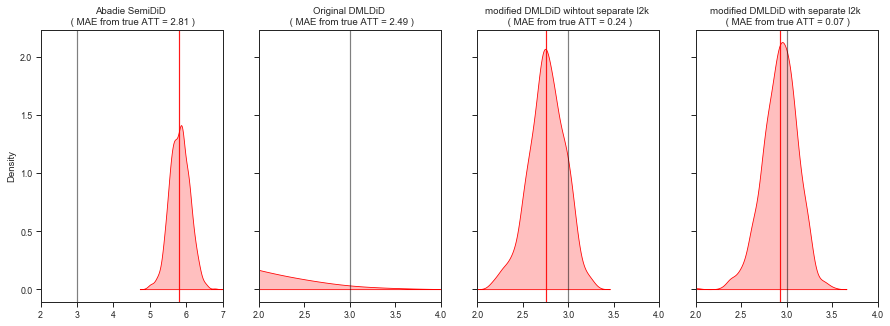

In [7]:
_label = [
    f"Abadie SemiDiD \n ( MAE from true ATT = {np.abs(3-np.mean(abadie_semidid)):.2f} )",
    f"Original DMLDiD \n ( MAE from true ATT = {np.abs(3-np.mean(chang_dml)):.2f} )",
    f"modified DMLDiD wihtout separate l2k \n ( MAE from true ATT = {np.abs(3-np.mean(lgbm_dml)):.2f} )",
    f"modified DMLDiD with separate l2k \n ( MAE from true ATT = {np.abs(3-np.mean(dml_with_separate)):.2f} )",
]
result_df = pd.DataFrame(
    {
        "abadie_semidid": abadie_semidid,
        "original_dmldid": chang_dml,
        "modified_dmldid": lgbm_dml,
        "modified_dmldid_with_separate": dml_with_separate,
    }
)
fig, ax = plt.subplots(1, 4, sharex="col", sharey="row", figsize=(15, 5))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
    # ax[i].hist(result_df[_col], bins=50,color="red",alpha=0.5)
    if i > 0:
        ax[i].set_xlim(2, 4)

    else:
        ax[i].set_xlim(2, 7)

    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), color="red", alpha=0.9)
    ax[i].set_xlabel("")

fig.savefig("../fig/simdata_result_unobserved_ps_lgbm.png", dpi=300)
plt.show()

In [8]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
abadie_semidid,1000.0,5.811777,0.270938,4.928545,5.623209,5.816876,6.001680,6.784705
original_dmldid,1000.0,0.512278,1.175491,-4.492156,-0.210372,0.639343,1.330016,3.527558
modified_dmldid,1000.0,2.757814,0.200977,1.876274,2.632000,2.759804,2.893465,3.306095
modified_dmldid_with_separate,1000.0,2.925993,0.190667,2.007561,2.803066,2.936806,3.049328,3.514180


In [9]:
result_df.to_csv("../sim_results/dimldid_rcs_with_simdata_lgbm.csv", index=False)

In [10]:
print("Done")

Done
